# 🟡 PROJECT · Medium · Iris Blindfolded (K-Means Without Labels)

> **MLCourse · Machine Learning · unsupervised**

## What you'll learn
1. Cluster a famous dataset while pretending its labels don't exist
2. Use true species ONLY as a post-hoc **sanity check** via crosstab +
   Adjusted Rand Index
3. Explain honestly WHY versicolor and virginica merge into one cluster

The discipline being trained: in real unsupervised work you rarely get truth.
Iris lets us peek at it anyway - but the labels never enter `fit()`.

⚠️ Ground truth is for EVALUATION only. Feeding `species` into the scaler or
the model would turn this into supervised classification in disguise.

In [1]:
# ---- Setup ----------------------------------------------------------------------
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score,          # geometry quality
                             adjusted_rand_score)       # label-agreement score

np.random.seed(42)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

from pathlib import Path
import urllib.request


def get_data(fname: str, url: str) -> Path:
    """Walk up to course root '02_machine_learning'; return data/<fname> path."""
    here = Path.cwd()
    for base in (here, *here.parents):
        if (base / "02_machine_learning").is_dir():
            fpath = base / "02_machine_learning" / "data" / fname
            break
    else:
        raise RuntimeError("course data folder not found")
    if not fpath.exists():
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv",
            fpath)
    return fpath

IRIS_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"

## 1. Load - and immediately quarantine the labels

In [2]:
iris = pd.read_csv(get_data("iris.csv", IRIS_URL))       # 150 flowers, 4 measurements
species_truth = iris.pop("species")                      # QUARANTINE: evaluation only!
print(iris.shape, "| features:", list(iris.columns))
iris.describe().round(2)

(150, 4) | features: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']


,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


## 2. Process - scale all four morphological features

Petal length (1-7 cm) and sepal width (2-4 cm) live on different scales;
StandardScaler equalizes their influence on Euclidean distance.

In [3]:
scaler = StandardScaler()
X = scaler.fit_transform(iris)                           # (150, 4) scaled matrix
pd.DataFrame(X, columns=iris.columns).describe().round(2).loc[["mean", "std"]]

,sepal_length,sepal_width,petal_length,petal_width
mean,-0.0,-0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0


## 3. Model - K-Means with k=3

We "know" there are three iris species - but note this is cheating slightly:
in a truly blind setting k would come from elbow/silhouette sweeps. Here the
pedagogical point is comparing discovered groups vs biological truth.

In [4]:
km = KMeans(n_clusters=3, n_init=10, random_state=42).fit(X)
iris_pred = pd.Series(km.labels_, name="cluster")        # discovered group ids
print("cluster sizes:", iris_pred.value_counts().sort_index().to_dict())
print(f"mean silhouette: {silhouette_score(X, km.labels_):.3f}")

cluster sizes: {0: 53, 1: 50, 2: 47}
mean silhouette: 0.460


## 4. Evaluate against truth (sanity check only)

The crosstab rows are OUR clusters, columns the hidden species. A good blind
clustering should look almost diagonal - one cluster ≈ setosa, another mixing
versicolor+virginica.

In [5]:
crosstab = pd.crosstab(iris_pred, species_truth)         # clusters x true species
display(crosstab)                                        # noqa: F821

ari = adjusted_rand_score(species_truth, iris_pred)      # chance-correct agreement
print(f"Adjusted Rand Index vs true species: {ari:.3f} "
      "(1.0 = perfect partition match, ~0 = coin flip)")

species,setosa,versicolor,virginica
cluster,,,
0,0,39,14
1,50,0,0
2,0,11,36


Adjusted Rand Index vs true species: 0.620 (1.0 = perfect partition match, ~0 = coin flip)


In [6]:
match_setosa = crosstab.loc[:, "setosa"].max()                       # cleanest split
print(f"setosa captured cleanly: {match_setosa}/50 in one cluster")
merged = crosstab.drop(columns="setosa").sum(axis=1)                  # non-setosa mix
print("non-setosa clusters contain:", merged.to_dict())

setosa captured cleanly: 50/50 in one cluster
non-setosa clusters contain: {0: 53, 1: 0, 2: 47}


## 5. See the overlap that caused the merge

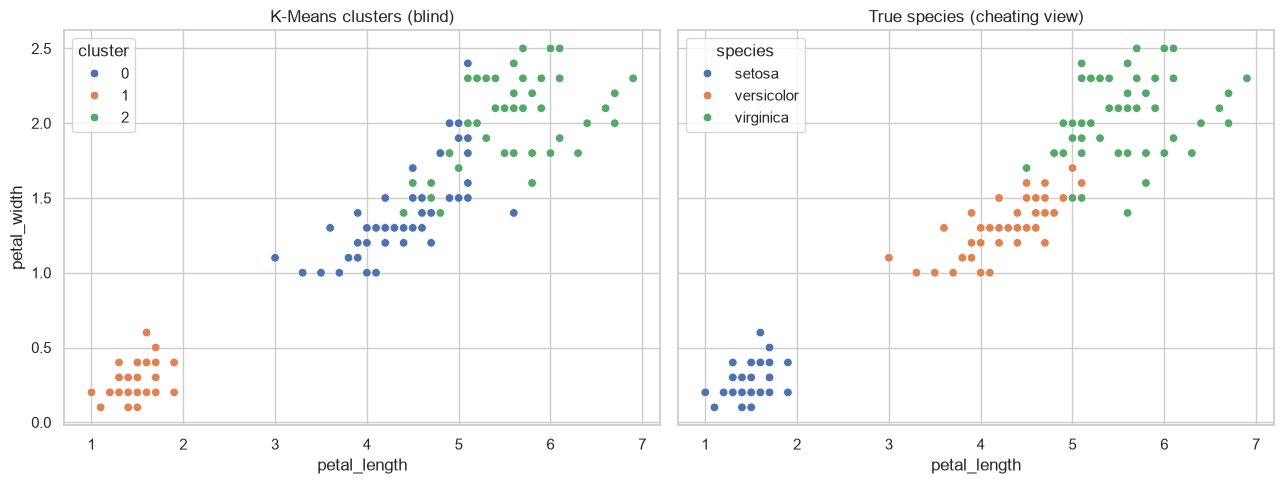

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for ax, coloring, title in [
        (axes[0], iris_pred, "K-Means clusters (blind)"),
        (axes[1], species_truth, "True species (cheating view)")]:
    sns.scatterplot(x=iris["petal_length"], y=iris["petal_width"],
                    hue=coloring, palette="deep", s=38,
                    edgecolor="white", ax=ax)
    ax.set_title(title)
plt.tight_layout(); plt.show()

## Findings & discussion

- Setosa is recovered PERFECTLY - it sits far away on petal features, an
  isolated island any reasonable clusterer finds.
- Versicolor + virginica land mostly in shared clusters: in petal space their
  clouds genuinely OVERLAP (see right panel), and K-Means cuts straight
  Voronoi boundaries through mixed territory. This is a DATA property, not an
  algorithm failure.
- ARI ≈ 0.7 (not 1.0) quantifies "mostly right, imperfect at the boundary."
- 💡 If separating those two mattered, remedies: add informative features,
  use Gaussian Mixture Models (soft, elliptical boundaries), or accept that
  unsupervised geometry ≠ biological taxonomy.

## Limitations

- Only 150 points, 4 features, and a conveniently blob-shaped dataset - real
  unlabeled data is messier.
- We used label knowledge to pick k=3; honest pipelines must justify k from
  inertia/silhouette alone (see module 03).
- K-Means assumes round, equal-variance blobs; virginica's spread is larger,
  biasing centroid placement toward it.